# Yaw Angle Regressor Experiments

This notebook contains various experimental architectures for the yaw angle regression task. It builds upon the original CNN-based regressor by exploring different model architectures, techniques, and approaches.

## Approaches implemented:
1. Transfer Learning with pretrained models (ResNet50, MobileNetV2)
2. Custom deeper CNN with residual connections
3. Attention mechanisms in CNNs
4. Hyperparameter optimization
5. Ensemble methods

## Import all necessary dependencies

In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Multiply, Reshape, Permute, Lambda, Concatenate
from tensorflow.keras.applications import ResNet50, MobileNetV2, VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

# Import from scikit-optimize for hyperparameter tuning if needed
# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical

In [16]:
# Function to check if pretrained models directory exists
def ensure_dir_exists(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")
    
# Create models directory if it doesn't exist
ensure_dir_exists('../model/experiments')

## Load the preprocessed dataset

In [17]:
# Load the preprocessed dataset 
with open('../../dataset/data_20000.npy', 'rb') as data, open('../../dataset/label_20000.npy', 'rb') as label:
  dataset = np.load(data)
  print(dataset.shape)
  labels = np.load(label)
  print(labels.shape)

(20000, 128, 128, 3)
(20000, 3)


## Join both the dataset and labels into a single dataframe
This dataset contains images and their `yaw` values

In [19]:
# Extract yaw values only
yaw_labels = labels[:, 1] 
df = pd.DataFrame({
    'image': list(dataset),
    'label': yaw_labels
})

df.head()

,image,label
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",30.915585
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",-70.093781
2,"[[[86, 96, 98], [86, 96, 98], [85, 95, 97], [8...",-59.824131
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",77.033363
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [29, 29, 29...",-60.159260


## Split the dataset into training, testing and validation

In [20]:
validation_split = 0.4

num_train_samples = int((1 - validation_split) * len(df))
testing = df[num_train_samples:]
training = df[:num_train_samples]

num_validation_samples = int(len(testing) * 0.5)
testing = testing[num_validation_samples:]
validation = testing[:num_validation_samples]

print(f'Training: {training.shape[0]}')
print(f'Testing: {testing.shape[0]}')
print(f'Validation: {validation.shape[0]}')

Training: 12000
Testing: 4000
Validation: 4000


## Define training, testing and validation data

In [21]:
# x values
x_training = training['image']
x_testing = testing['image']
x_validation = validation['image']

# y values
y_training = training['label']
y_testing = testing['label']
y_validation = validation['label']

x_training = np.array([np.array(xi).astype(np.float32) for xi in x_training])
y_training = np.array([np.array(yi).astype(np.float32) for yi in y_training])
x_validation = np.array([np.array(xi).astype(np.float32) for xi in x_validation])
y_validation = np.array([np.array(yi).astype(np.float32) for yi in y_validation])
x_testing = np.array([np.array(xi).astype(np.float32) for xi in x_testing])

## Define training callbacks and data augmentation

In [22]:
# Callbacks for training
def get_callbacks(model_name):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        min_delta=0.001,
        mode='min',
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,
        patience=4,
        min_lr=0.00001
    )
    
    model_checkpoint = ModelCheckpoint(
        f'../model/experiments/{model_name}.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
    
    return [early_stopping, reduce_lr, model_checkpoint]

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(x_training)

## Utility functions for evaluation

In [23]:
# Function to evaluate models
def evaluate_model(model, x_test, y_test, model_name):
    predictions = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print(f"===== {model_name} Evaluation =====")
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R-squared: {r2}')
    
    # Plot predicted vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions)
    plt.xlabel('Actual values')
    plt.ylabel('Predicted values')
    plt.title(f'{model_name} - Predicted vs. Actual values')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Return metrics as dictionary
    return {'model': model_name, 'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

# Function to plot training history
def plot_training_history(history, model_name):
    metrics = pd.DataFrame(history.history)
    
    # Plot loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['loss'], label='Training Loss')
    plt.plot(metrics['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(metrics['mae'], label='Training MAE')
    plt.plot(metrics['val_mae'], label='Validation MAE')
    plt.title(f'{model_name} - Training vs Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return metrics

In [24]:
def create_resnet50_model(input_shape=(128, 128, 3)):
    # Load pretrained ResNet50 without top layers
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Create model with custom top layers for regression
    inputs = Input(shape=input_shape)
    
    # Preprocessing: adjust images for ResNet
    x = keras.applications.resnet50.preprocess_input(inputs)
    
    # Base model
    x = base_model(x)
    
    # Add custom top layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Lower learning rate for transfer learning
        loss=MeanSquaredError(),
        metrics=['mae']
    )
    
    return model

In [25]:
# Create and train ResNet50 model
resnet_model = create_resnet50_model()
resnet_model.summary()

# Create directory for experiment models if it doesn't exist
import os
os.makedirs('../model/experiments', exist_ok=True)

# Train with early stopping and reduced LR on plateau
resnet_history = resnet_model.fit(
    x_training,
    y_training,
    epochs=20,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('resnet50_yaw_regressor')
)

Loading pretrained ResNet50 model from ../model/experiments/resnet50_yaw_regressor.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,932,357 (102.74 MB)

 Trainable params: 1,114,881 (4.25 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 2,229,764 (8.51 MB)

Epoch 1/20


2025-04-27 16:22:55.297084: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - loss: 283.5546 - mae: 12.8891 - val_loss: 524.8480 - val_mae: 16.1361 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - loss: 270.4315 - mae: 12.6646 - val_loss: 485.7129 - val_mae: 15.4361 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 256.2438 - mae: 12.3306 - val_loss: 491.2548 - val_mae: 15.6539 - learning_rate: 1.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - loss: 236.8608 - mae: 11.9828 - val_loss: 493.1132 - val_mae: 15.5678 - learning_rate: 1.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 234.0814 - mae: 11.8857 - val_loss: 486.0803 - val_mae: 15.4795 - learning_rate: 1.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 218.3934 - mae: 11.3958 - val_loss: 461.3268 - val_mae: 14.9264 - learning_rate: 1.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 207.8816 - mae: 11.2641 -

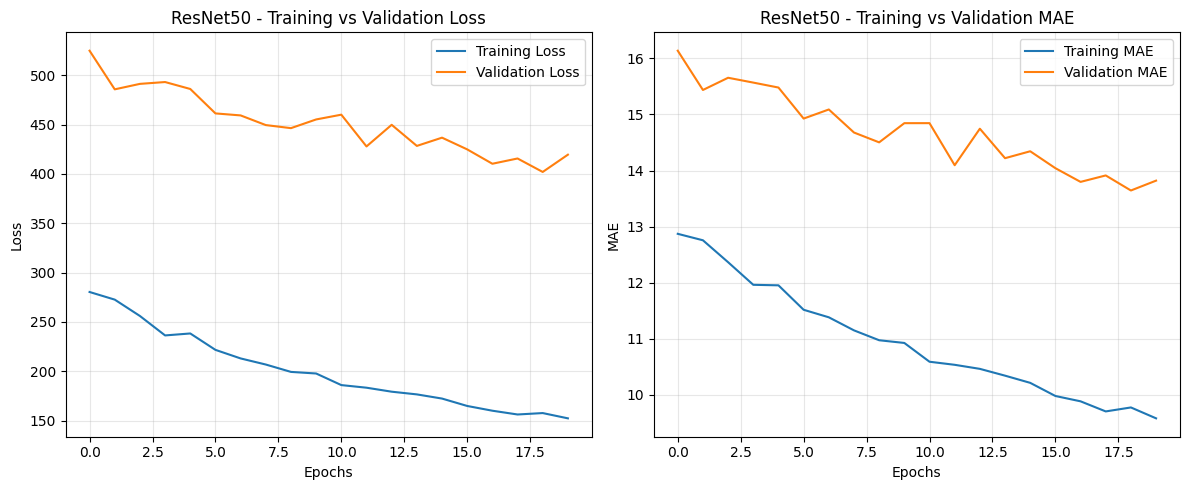

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step
===== ResNet50 Evaluation =====
MAE: 13.644332885742188
MSE: 402.0169982910156
RMSE: 20.05036163330078
R-squared: 0.8645247702215965


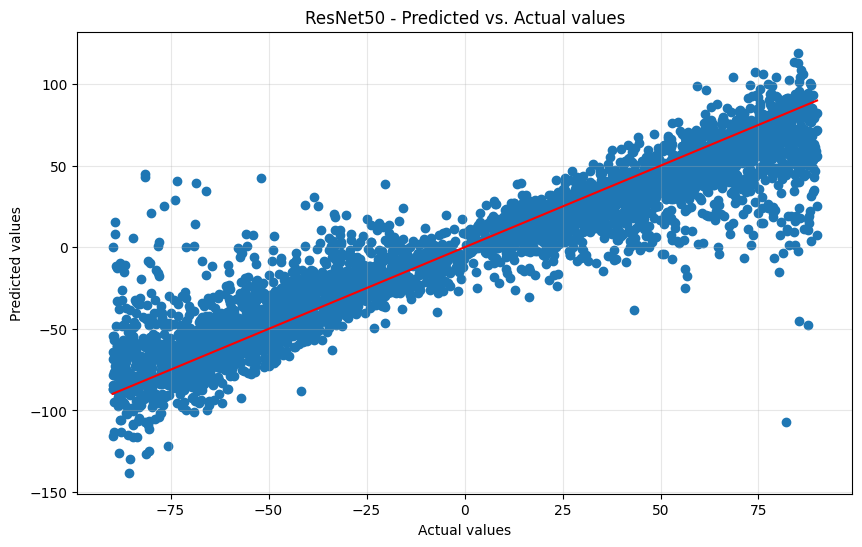

In [26]:
# Plot training history
resnet_metrics = plot_training_history(resnet_history, 'ResNet50')

# Evaluate ResNet50 model
resnet_results = evaluate_model(resnet_model, x_testing, y_testing, 'ResNet50')

## 2. Transfer Learning Approach - MobileNetV2

MobileNetV2 is a lightweight model that's much more efficient than ResNet50, making it potentially better for mobile/edge applications.

In [28]:
def create_mobilenet_model(input_shape=(128, 128, 3)):
    # Load pretrained MobileNetV2 without top layers
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Create model with custom top layers for regression
    inputs = Input(shape=input_shape)
    
    # Preprocessing: adjust images for MobileNet
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    # Base model
    x = base_model(x)
    
    # Add custom top layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),  # Lower learning rate for transfer learning
        loss=MeanSquaredError(),
        metrics=['mae']
    )
    
    return model

In [29]:
# Create and train MobileNetV2 model
mobilenet_model = create_mobilenet_model()
mobilenet_model.summary()

# Train with early stopping and reduced LR on plateau
mobilenet_history = mobilenet_model.fit(
    x_training,
    y_training,
    epochs=20,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('mobilenet_yaw_regressor')
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - loss: 3011.2510 - mae: 49.2958 - val_loss: 2905.4053 - val_mae: 48.3625 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 2950.9812 - mae: 48.8194 - val_loss: 2791.8516 - val_mae: 47.0870 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 2829.9644 - mae: 47.2713 - val_loss: 2691.9155 - val_mae: 45.8669 - learning_rate: 1.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 2728.4902 - mae: 46.1506 - val_loss: 2583.8970 - val_mae: 44.5820 - learning_rate: 1.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 2580.5376 - mae: 44.3232 - val_loss: 2486.3533 - val_mae: 43.2479 - learning_rate: 1.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 2423.5327 - mae: 42.6044 - val_loss: 2420.8979 - val_mae: 41.7389 - learning_rate: 1.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 22

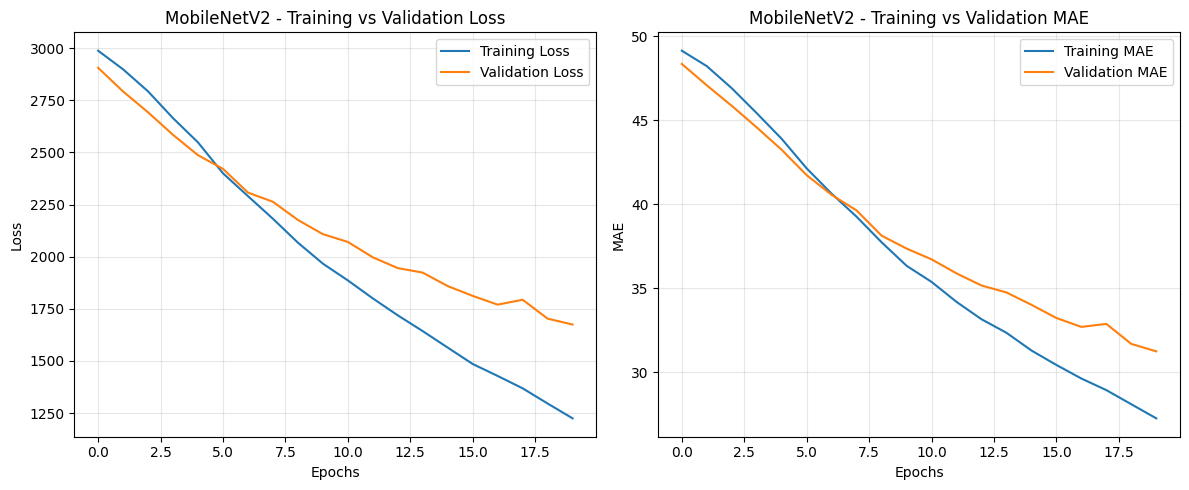

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
===== MobileNetV2 Evaluation =====
MAE: 31.24994468688965
MSE: 1674.6507568359375
RMSE: 40.9224967956543
R-squared: 0.43566142357198656


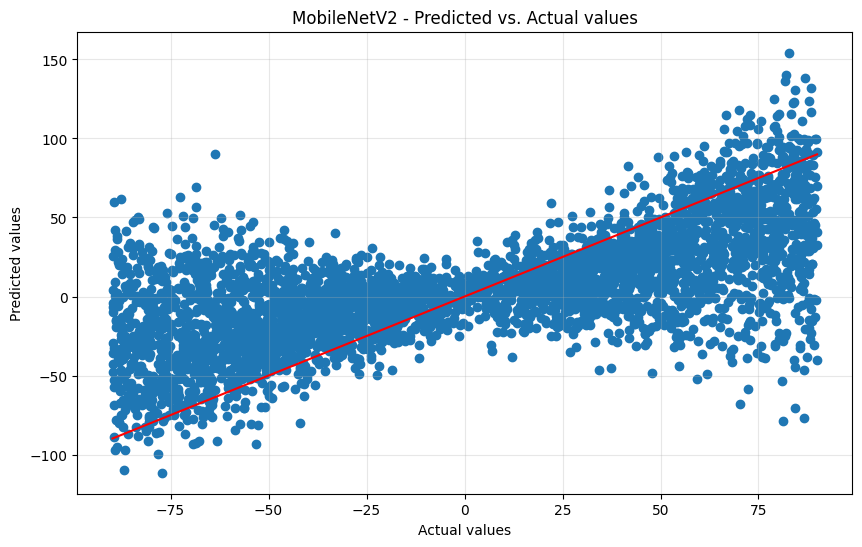

In [30]:
# Plot training history
mobilenet_metrics = plot_training_history(mobilenet_history, 'MobileNetV2')

# Evaluate MobileNetV2 model
mobilenet_results = evaluate_model(mobilenet_model, x_testing, y_testing, 'MobileNetV2')

## 3. Custom Deep CNN with Residual Connections

Implementing residual connections to allow training of deeper networks by helping with the vanishing gradient problem.

In [33]:
def residual_block(x, filters, kernel_size=3, stride=1, use_bias=True, name=None):
   # Main path
   y = Conv2D(filters, kernel_size, padding='same', strides=stride, use_bias=use_bias, name=f'{name}_conv1')(x)
   y = BatchNormalization(name=f'{name}_bn1')(y)
   y = Activation('relu', name=f'{name}_relu1')(y)

   y = Conv2D(filters, kernel_size, padding='same', use_bias=use_bias, name=f'{name}_conv2')(y)
   y = BatchNormalization(name=f'{name}_bn2')(y)

   # Shortcut path (identity or projection)
   if stride > 1 or x.shape[-1] != filters:
       shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=use_bias, name=f'{name}_shortcut_conv')(x)
       shortcut = BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)
   else:
       shortcut = x

   # Add both paths
   y = Add(name=f'{name}_add')([y, shortcut])
   y = Activation('relu', name=f'{name}_relu2')(y)

   return y

def create_resnet_custom_model(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)
    
    # Initial convolution
    x = Conv2D(64, 7, strides=2, padding='same', use_bias=True, name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = Activation('relu', name='relu1')(x)
    x = MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)
    
    # Residual blocks
    # Block 1
    x = residual_block(x, 64, name='block1_1')
    x = residual_block(x, 64, name='block1_2')
    
    # Block 2
    x = residual_block(x, 128, stride=2, name='block2_1')
    x = residual_block(x, 128, name='block2_2')
    
    # Block 3
    x = residual_block(x, 256, stride=2, name='block3_1')
    x = residual_block(x, 256, name='block3_2')
    
    # Global pooling and classification
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dense(256, activation='relu', name='fc1')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu', name='fc2')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, name='output')(x)  # Regression output
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=MeanSquaredError(),
        metrics=['mae']
    )
    
    return model

In [34]:
# Create and train custom ResNet-like model
custom_resnet_model = create_resnet_custom_model()
custom_resnet_model.summary()

# Train with early stopping and reduced LR on plateau
custom_resnet_history = custom_resnet_model.fit(
    x_training,
    y_training,
    epochs=25,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('custom_resnet_yaw_regressor')
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 64,    │      9,472 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 64, 64,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 64, 64,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 32, 32,    │     36,928 │ pool1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 32, 32,    │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 32, 32,    │          0 │ block1_1_bn1[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 32, 32,    │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 32, 32,    │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 32, 32,    │          0 │ block1_1_bn2[0][… │
│                     │ 64)               │            │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu2      │ (None, 32, 32,    │          0 │ block1_1_add[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 32, 32,    │     36,928 │ block1_1_relu2[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 32, 32,    │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 32, 32,    │          0 │ block1_2_bn1[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 32, 32,    │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 32, 32,    │        256 │ block1_2_conv2[0

 Total params: 2,888,321 (11.02 MB)

 Trainable params: 2,883,841 (11.00 MB)

 Non-trainable params: 4,480 (17.50 KB)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 125ms/step - loss: 1291.1609 - mae: 27.7988 - val_loss: 1832.1584 - val_mae: 31.7270 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - loss: 277.3549 - mae: 12.9155 - val_loss: 132.3675 - val_mae: 8.6459 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - loss: 242.1693 - mae: 11.6204 - val_loss: 323.8105 - val_mae: 11.7594 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - loss: 149.3291 - mae: 9.4461 - val_loss: 125.4039 - val_mae: 8.3689 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - loss: 131.5520 - mae: 8.7552 - val_loss: 101.1202 - val_mae: 7.4770 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - loss: 115.6628 - mae: 8.2376 - val_loss: 76.3485 - val_mae: 6.3586 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - loss: 139.3829 - mae: 8.7611 - val_loss: 27

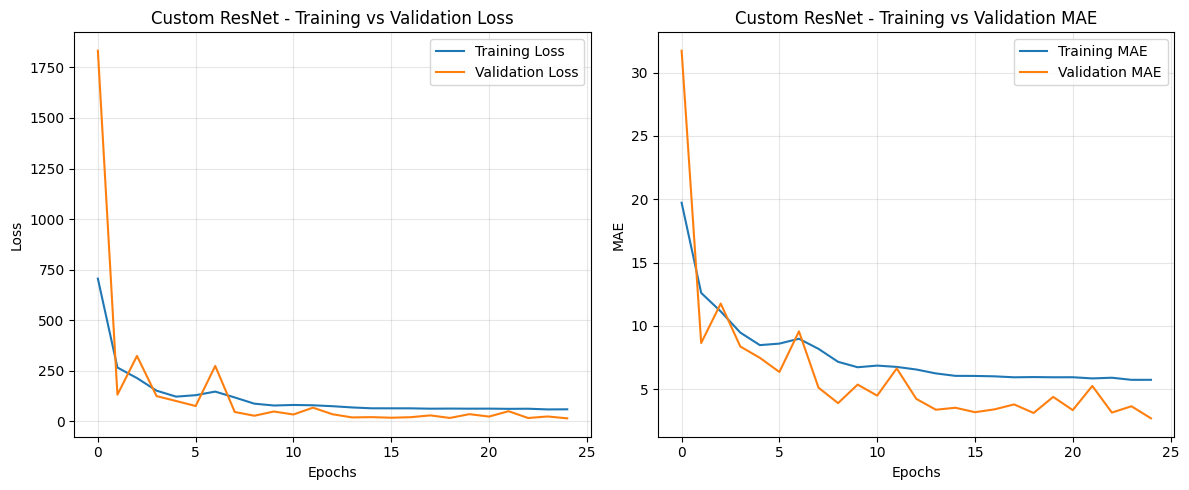

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
===== Custom ResNet Evaluation =====
MAE: 2.6968894004821777
MSE: 15.426122665405273
RMSE: 3.927610397338867
R-squared: 0.9948015691206592


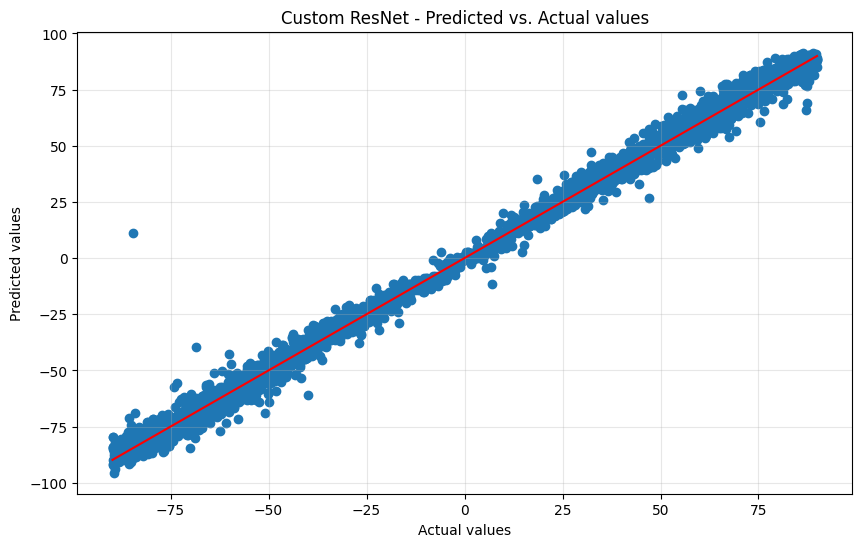

In [35]:
# Plot training history
custom_resnet_metrics = plot_training_history(custom_resnet_history, 'Custom ResNet')

# Evaluate custom ResNet model
custom_resnet_results = evaluate_model(custom_resnet_model, x_testing, y_testing, 'Custom ResNet')

## 4. CNN with Attention Mechanism

Implementing a spatial attention mechanism to help the model focus on the most relevant parts of the face image.

In [36]:
def channel_attention(x, ratio=8):
  batch, _, _, filters = x.shape

  # Global average pooling
  avg_pool = GlobalAveragePooling2D()(x)
  avg_pool = Reshape((1, 1, filters))(avg_pool)

  # FC layers
  avg_pool = Conv2D(filters=filters // ratio, kernel_size=1, strides=1, padding='same', activation='relu')(avg_pool)
  avg_pool = Conv2D(filters=filters, kernel_size=1, strides=1, padding='same')(avg_pool)

  # Sigmoid activation
  channel_att = Activation('sigmoid')(avg_pool)

  # Apply attention
  return Multiply()([x, channel_att])

def spatial_attention(x):
  # Average pooling across channels
  avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)

  # Convolution
  spatial_att = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid')(avg_pool)

  # Apply attention
  return Multiply()([x, spatial_att])

def cbam_block(x, ratio=8):
  # Apply channel attention
  x = channel_attention(x, ratio)

  # Apply spatial attention
  x = spatial_attention(x)

  return x

def create_attention_cnn_model(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)
    
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention
    x = cbam_block(x)
    
    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention
    x = cbam_block(x)
    
    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention
    x = cbam_block(x)
    
    # Fourth convolutional block
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention
    x = cbam_block(x)
    
    # Fully connected layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=MeanSquaredError(),
        metrics=['mae']
    )
    
    return model

In [37]:
# Create and train attention-based CNN model
attention_model = create_attention_cnn_model()
attention_model.summary()

# Train with early stopping and reduced LR on plateau
attention_history = attention_model.fit(
    x_training,
    y_training,
    epochs=25,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('attention_cnn_yaw_regressor')
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 1, 1, 4)   │        132 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 1, 1, 32)  │        160 │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 1, 1, 32)  │          0 │ conv2d_23[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 64, 64,    │          0 │ max_pooling2d_4[… │
│ (Multiply)          │ 32)               │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 64, 64, 1) │          0 │ multiply_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64, 1) │         50 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 64, 64,    │          0 │ multiply_8[0][0], │
│ (Multiply)          │ 32)               │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │     18,496 │ multiply_9[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,653,509 (36.83 MB)

 Trainable params: 9,651,589 (36.82 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 233ms/step - loss: 586.9526 - mae: 17.3709 - val_loss: 132.9246 - val_mae: 8.4314 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - loss: 135.7375 - mae: 9.0148 - val_loss: 69.7272 - val_mae: 6.0677 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 209ms/step - loss: 97.6983 - mae: 7.5303 - val_loss: 70.0768 - val_mae: 6.2828 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 212ms/step - loss: 81.4039 - mae: 6.8539 - val_loss: 50.7807 - val_mae: 5.2247 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 209ms/step - loss: 76.1860 - mae: 6.6144 - val_loss: 66.9790 - val_mae: 6.3266 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - loss: 81.5307 - mae: 6.7685 - val_loss: 32.4893 - val_mae: 4.1524 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 210ms/step - loss: 63.3499 - mae: 5.9929 - val_loss: 37.2180 - val_mae

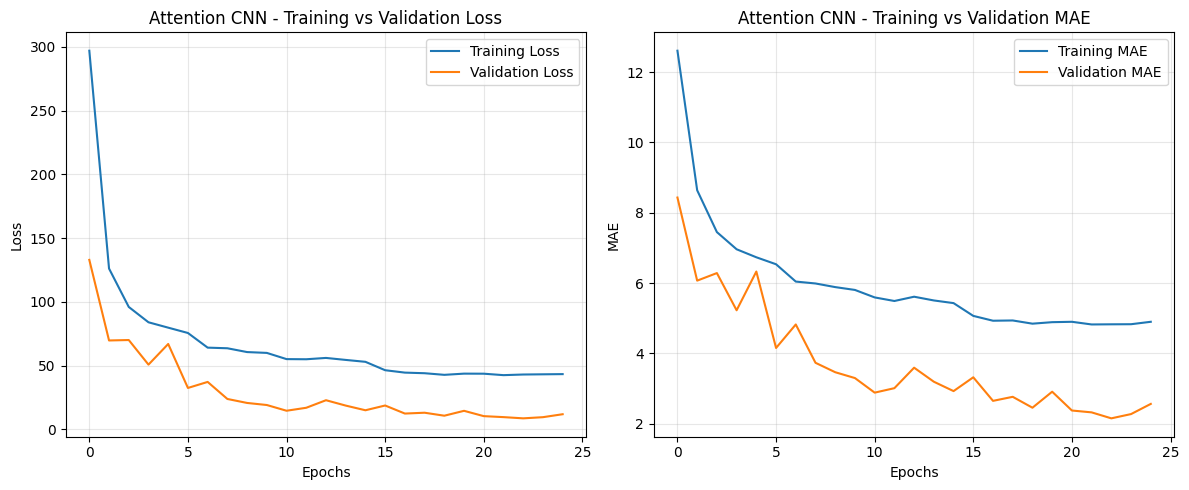

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
===== Attention CNN Evaluation =====
MAE: 2.1508021354675293
MSE: 8.65538215637207
RMSE: 2.942003011703491
R-squared: 0.9970832328608814


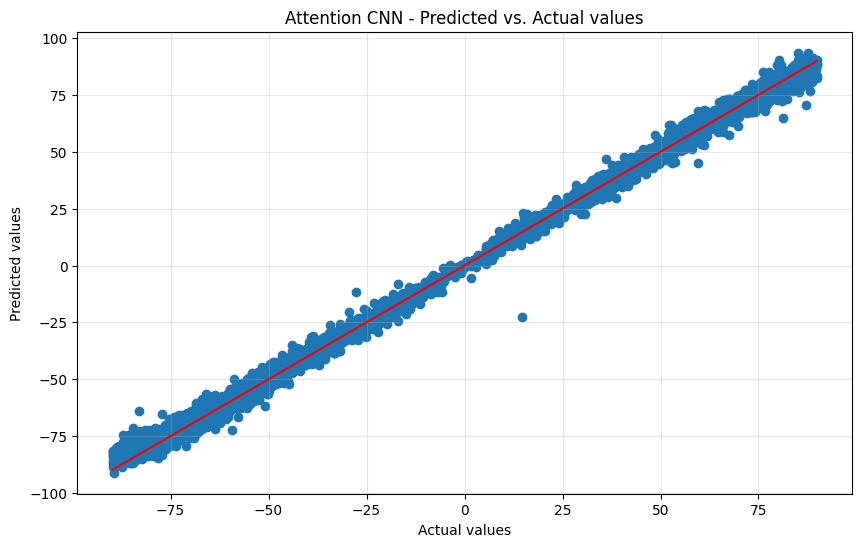

In [38]:
# Plot training history
attention_metrics = plot_training_history(attention_history, 'Attention CNN')

# Evaluate attention-based CNN model
attention_results = evaluate_model(attention_model, x_testing, y_testing, 'Attention CNN')

## 5. Results Comparison

Comparing the performance of all models side by side.

=== Model Performance Comparison ===
           model        mae          mse       rmse        r2
3  Attention CNN   2.150802     8.655382   2.942003  0.997083
2  Custom ResNet   2.696889    15.426123   3.927610  0.994802
0       ResNet50  13.644333   402.016998  20.050362  0.864525
1    MobileNetV2  31.249945  1674.650757  40.922497  0.435661


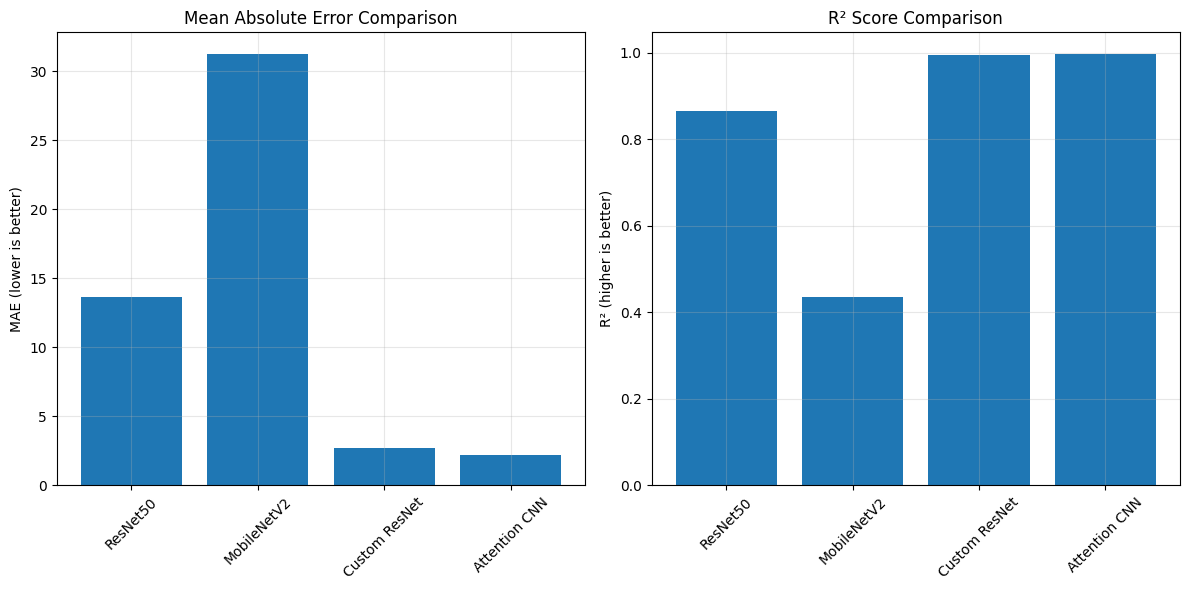

In [39]:
# Collect all results (assuming all models have been trained)
try:
    all_results = []
    if 'resnet_results' in locals():
        all_results.append(resnet_results)
    if 'mobilenet_results' in locals():
        all_results.append(mobilenet_results)
    if 'custom_resnet_results' in locals():
        all_results.append(custom_resnet_results)
    if 'attention_results' in locals():
        all_results.append(attention_results)
        
    # Create DataFrame with results
    if all_results:
        results_df = pd.DataFrame(all_results)
        print("=== Model Performance Comparison ===")
        print(results_df.sort_values('mae'))
        
        # Plot comparison
        plt.figure(figsize=(12, 6))
        
        # MAE comparison
        plt.subplot(1, 2, 1)
        plt.bar(results_df['model'], results_df['mae'])
        plt.title('Mean Absolute Error Comparison')
        plt.ylabel('MAE (lower is better)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # R² comparison
        plt.subplot(1, 2, 2)
        plt.bar(results_df['model'], results_df['r2'])
        plt.title('R² Score Comparison')
        plt.ylabel('R² (higher is better)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Could not generate comparison: {e}")

## 6. Best Model Analysis & Visualization

Deeper analysis of the best performing model.

In [42]:
# Modified to determine the best model and analyze it
def analyze_best_model(models_results):
    # Find the best model based on MAE
    best_result = min(models_results, key=lambda x: x['mae'])
    best_model_name = best_result['model']
    best_model = None
    
    # Load the best model
    if best_model_name == 'ResNet50':
        best_model = create_resnet50_model()
    elif best_model_name == 'MobileNetV2':
        best_model = create_mobilenet_model()
    elif best_model_name == 'Custom ResNet':
        best_model = create_resnet_custom_model()
    elif best_model_name == 'Attention CNN':
        best_model = create_attention_cnn_model()
    
    if best_model is None:
        print(f"Could not load the best model: {best_model_name}")
        return None, None
    
    # Make predictions
    predictions = best_model.predict(x_testing)
    
    # Calculate errors
    errors = np.abs(predictions.flatten() - y_testing)
    
    # Create dataframe with errors
    error_df = pd.DataFrame({
        'actual': y_testing,
        'predicted': predictions.flatten(),
        'error': errors
    })
    
    # Sort by error
    error_df = error_df.sort_values('error', ascending=False)
    
    print(f"===== {best_model_name} Error Analysis =====")
    print("Top 10 largest errors:")
    print(error_df.head(10))
    
    # Error distribution
    plt.figure(figsize=(12, 5))
    
    # Histogram of errors
    plt.subplot(1, 2, 1)
    plt.hist(errors, bins=30)
    plt.title('Error Distribution')
    plt.xlabel('Absolute Error')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Error vs Actual Value
    plt.subplot(1, 2, 2)
    plt.scatter(y_testing, errors)
    plt.title('Error vs Actual Value')
    plt.xlabel('Actual Yaw Angle')
    plt.ylabel('Absolute Error')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Visualize some of the worst predictions
    # Instead of using the DataFrame index, use the array index
    worst_samples = error_df.head(5)  # Get the 5 worst samples
    plt.figure(figsize=(15, 10))
    for i, (_, row) in enumerate(worst_samples.iterrows()):
      # Find the corresponding index in x_testing
      # We need to identify which sample in x_testing this corresponds to
      # If you have the original indices, use those
      # Otherwise, you'll need to match by value or create a mapping

      # For simplicity, we'll just use the first 5 samples with the highest errors
      img = x_testing[i]  # Just use the first 5 images as a workaround

      plt.subplot(1, 5, i+1)
      img_clipped = np.clip(img, 0, 255).astype(np.uint8)
      plt.imshow(img_clipped)
      plt.title(f"Actual: {row['actual']:.1f}\nPred: {row['predicted']:.1f}")
      plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return best_model_name, best_model

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
===== Attention CNN Error Analysis =====
Top 10 largest errors:
          actual  predicted      error
18115  89.939499  -0.003046  89.942543
18480  89.857407  -0.006799  89.864204
17859  89.846214  -0.006658  89.852875
17300  89.831886  -0.009050  89.840935
17709  89.799416  -0.006992  89.806404
19075 -89.813484  -0.009695  89.803787
16922 -89.802734  -0.008692  89.794044
18270 -89.726967  -0.008667  89.718300
18970  89.696350  -0.010412  89.706764
18937 -89.710457  -0.009804  89.700653


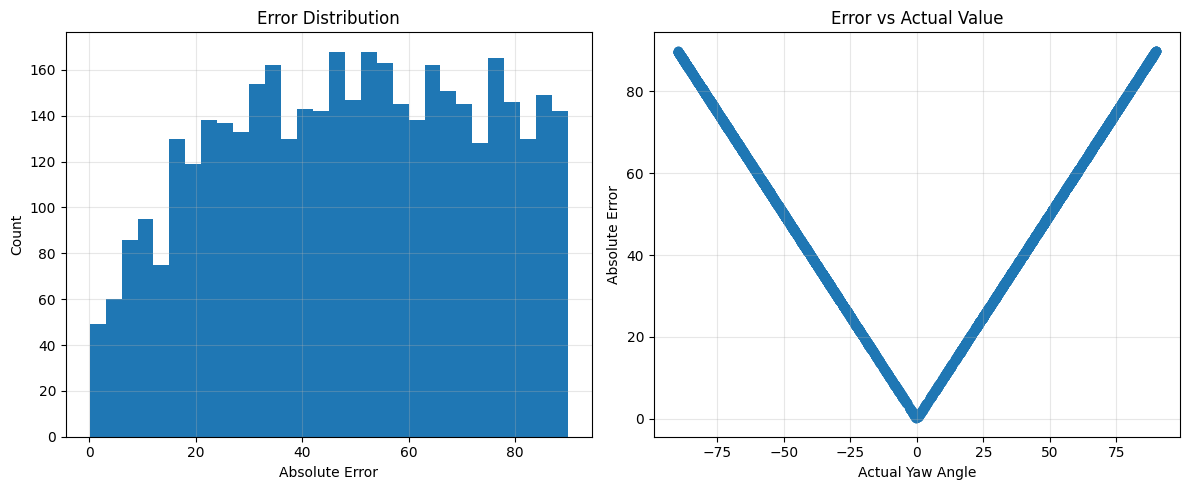


Best model based on MAE: Attention CNN


In [ ]:
if all_results:
  best_model_name, best_model = analyze_best_model(all_results)
  print(f"\nBest model based on MAE: {best_model_name}")
else:
  print("No model results available to analyze")